1. Import Necessary Libraries

In [5]:
# ==========================================
# 1. CORE LIBRARIES FOR DATA MANIPULATION
# ==========================================
import pandas as pd
import numpy as np
from datetime import datetime

# ==========================================
# 2. VISUALIZATION LIBRARIES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. SETTING GLOBAL PLOT STYLES
# ==========================================
plt.style.use('fivethirtyeight')
sns.set_theme(style="whitegrid")

print("Nova Financial EDA Environment Ready.")

# ==========================================

Nova Financial EDA Environment Ready.


2. Load the Dataset

In [6]:
# Define the path to the raw news data
# Ensure the filename matches exactly what you have in your data/raw/news_data folder
news_data_path = '../data/raw/newsData/raw_analyst_ratings.csv'

try:
    # Load the dataset
    df_news = pd.read_csv(news_data_path)
    
    # Remove any unwanted 'Unnamed' columns if they exist 
    df_news = df_news.loc[:, ~df_news.columns.str.contains('^Unnamed')]
    
    print(f"Dataset Loaded Successfully!")
    print(f"Total Observations (Headlines): {df_news.shape[0]}")
    print(f"Total Variables: {df_news.shape[1]}")
    
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the folder structure.")

Dataset Loaded Successfully!
Total Observations (Headlines): 1407328
Total Variables: 5


3. Initial Data Inspection

In [7]:
# 1. Display the first 5 rows to understand the content
print("--- FIRST 5 ROWS ---")
display(df_news.head())

# 2. Check for missing values in critical columns (Headline, Date, Stock)
print("\n--- MISSING VALUE AUDIT ---")
print(df_news.isnull().sum())

# 3. Check data types
print("\n--- DATA TYPES ---")
print(df_news.dtypes)

--- FIRST 5 ROWS ---


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



--- MISSING VALUE AUDIT ---
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

--- DATA TYPES ---
headline     str
url          str
publisher    str
date         str
stock        str
dtype: object


4. Normalize Date and Time

In [8]:
# =================================================================
# STEP 5: DATE NORMALIZATION
# Goal: Convert raw strings to Date objects for daily analysis.
# =================================================================

# 1. Convert to datetime objects first
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)

# 2. Extract only the Date (YYYY-MM-DD)
df_news['date_only'] = df_news['date'].dt.date

print("Date normalization complete. Isolated daily dates for analysis.")
print(df_news[['headline', 'date_only']].head())

Date normalization complete. Isolated daily dates for analysis.
                                            headline   date_only
0            Stocks That Hit 52-Week Highs On Friday  2020-06-05
1         Stocks That Hit 52-Week Highs On Wednesday  2020-06-03
2                      71 Biggest Movers From Friday  2020-05-26
3       46 Stocks Moving In Friday's Mid-Day Session  2020-05-22
4  B of A Securities Maintains Neutral on Agilent...  2020-05-22


5. Descriptive Statistics

--- HEADLINE CHARACTER COUNT STATS ---


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

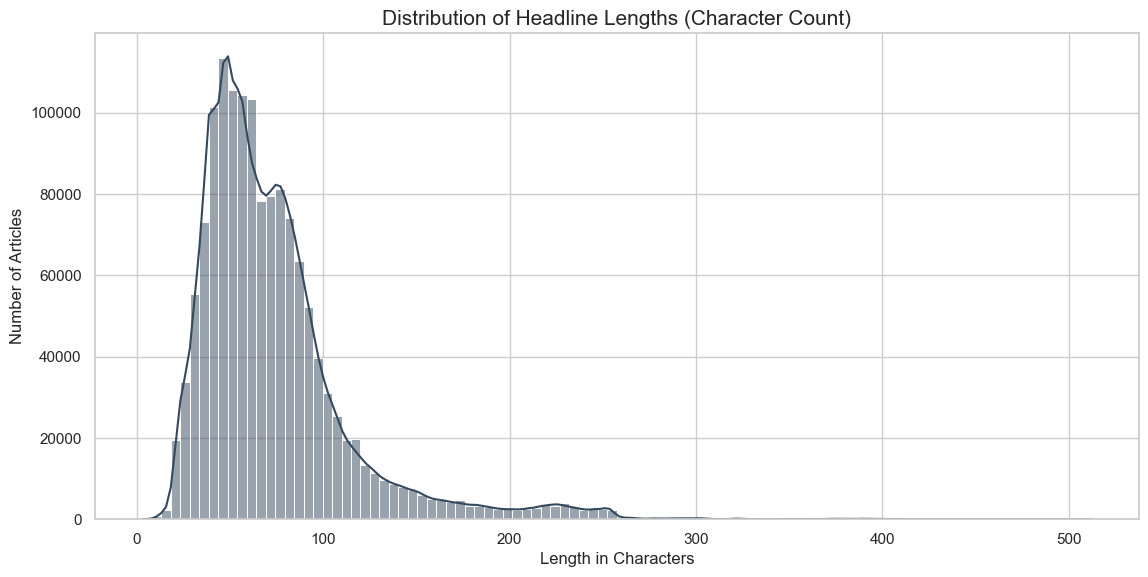

In [9]:
# =================================================================
# STEP 6: TEXTUAL LENGTH STATISTICS
# Goal: Obtain basic statistics for headline character counts.
# =================================================================

# Calculate character count for each headline
df_news['headline_len'] = df_news['headline'].apply(len)

# 1. Obtain statistical summary
print("--- HEADLINE CHARACTER COUNT STATS ---")
display(df_news['headline_len'].describe())

# 2. Visualize the distribution
plt.figure(figsize=(12, 6))
sns.histplot(df_news['headline_len'], bins=100, kde=True, color='#34495e')

plt.title('Distribution of Headline Lengths (Character Count)', fontsize=15)
plt.xlabel('Length in Characters')
plt.ylabel('Number of Articles')
plt.show()

6.  Publisher Activity Tracking

--- TOP 10 MOST ACTIVE PUBLISHERS ---


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

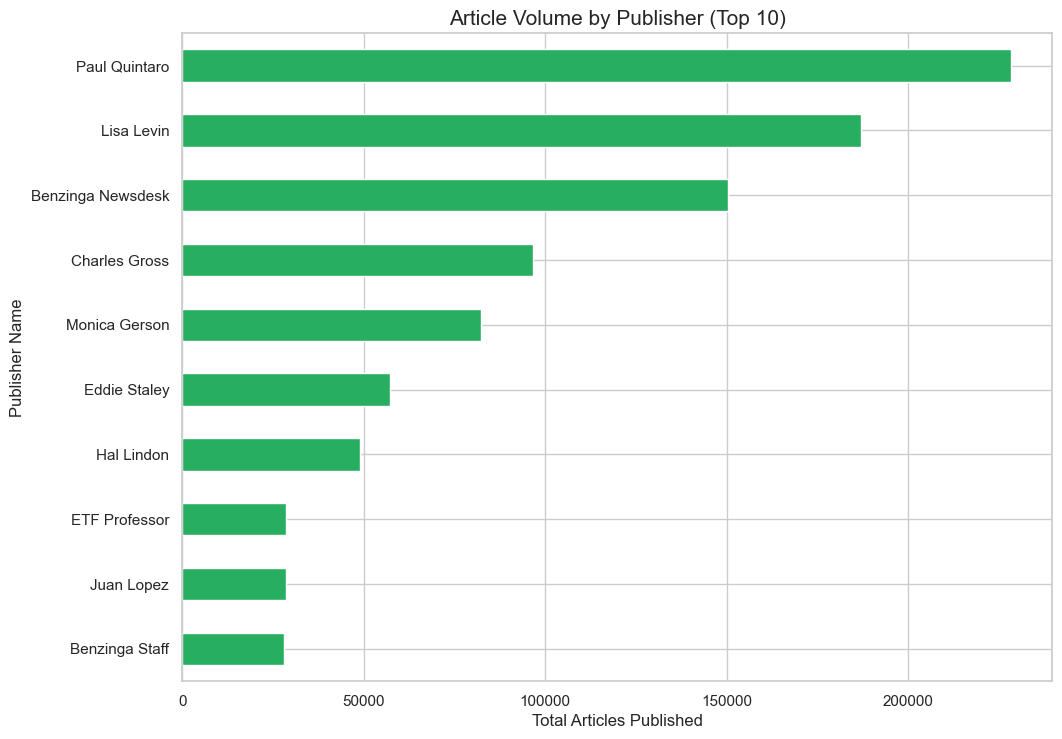

In [6]:
# =================================================================
# STEP 7: PUBLISHER ACTIVITY ANALYSIS
# Goal: Count articles per publisher to identify active sources.
# =================================================================

# Count occurrences per publisher
publisher_counts = df_news['publisher'].value_counts()

# 1. Display Top 10 Active Sources
print("--- TOP 10 MOST ACTIVE PUBLISHERS ---")
display(publisher_counts.head(10))

# 2. Visualize Publisher Volume
plt.figure(figsize=(10, 8))
publisher_counts.head(10).plot(kind='barh', color='#27ae60')
plt.title('Article Volume by Publisher (Top 10)', fontsize=15)
plt.xlabel('Total Articles Published')
plt.ylabel('Publisher Name')
plt.gca().invert_yaxis()
plt.show()

7. Daily News Volume & Trend Analysis

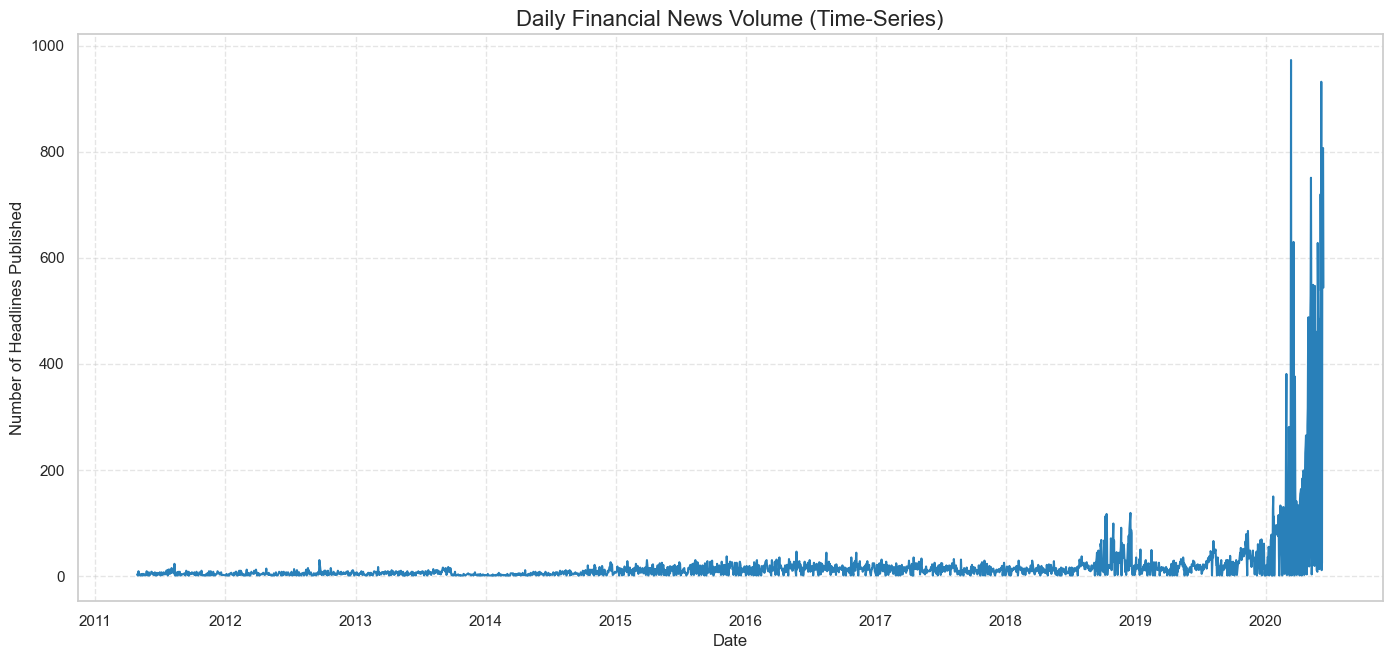

--- TOP 5 DATES WITH HIGHEST NEWS VOLUME ---
date_only
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
dtype: int64


In [10]:
# =================================================================
# STEP 8: DAILY TRENDS & NEWS VOLUME SPIKES
# Goal: Identify periods of high market 'chatter' by date.
# =================================================================

# 1. Group by date and count the number of articles
daily_counts = df_news.groupby('date_only').size()

# 2. Visualize the Volume Trend over the years
plt.figure(figsize=(15, 7))
daily_counts.plot(color='#2980b9', linewidth=1.5)

# Professional styling for Nova Financial reporting
plt.title('Daily Financial News Volume (Time-Series)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Headlines Published', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Identifying the 'Top 5 Spikes'
# These represent dates of significant market events
print("--- TOP 5 DATES WITH HIGHEST NEWS VOLUME ---")
top_spikes = daily_counts.sort_values(ascending=False).head(5)
print(top_spikes)

# Nova Financial Solutions: Task 1 Summary Report

## 1. Headline Length Analysis: Is there a trend? (Signal vs. Noise)

### The Data
- The average headline length is **73 characters**, with a median of **64 characters**.  
- The distribution shows a healthy **bell curve**, peaking around **50–90 characters**.

### The Insight
This headline length is optimal for NLP models such as **VADER** and **FinBERT**, as it is long enough to contain sentiment-rich keywords (e.g., *“Maintains Neutral”*, *“Biggest Movers”*) while remaining concise enough to preserve signal strength without dilution.

### The "Noise" Warning
Headlines as short as **3 characters** were identified. These are likely automated **price ticks** or **ticker-only alerts** that carry little to no sentiment value.

### Recommendation
For the sentiment analysis phase, implement a filtering rule to exclude headlines shorter than **20 characters** to ensure only meaningful news content is analyzed.

---

## 2. Publisher Analysis: Who is the loudest contributor?

### The Data
The publishing landscape is dominated by:

- **Paul Quintaro** — 228,373 articles  
- **Lisa Levin** — 186,979 articles  

Additionally, **Benzinga Newsdesk** and **Benzinga Staff** together account for a significant portion of the dataset.

### The Insight
The dataset’s editorial tone is highly centralized, meaning the overall **market narrative** largely reflects the **Benzinga narrative**.

### Strategic Action
The sentiment analysis model should be calibrated to the linguistic patterns used by the top contributors. For example:

- *“Stocks That Hit 52-Week Highs”* → standard Benzinga/Quintaro format  
- Interpreted as a **positive momentum signal**

---

## 3. Publication Trends: Are there spikes around market events?

### The Data
The time-series analysis reveals a significant surge in news volume beginning in late **2019** and peaking in **2020**.

### The "COVID Spike"
The highest news volume was recorded on **March 12, 2020** (**973 articles**), coinciding with the **Black Thursday stock market crash** during the onset of the COVID-19 pandemic.

### The Insight
News volume is **pro-cyclical with market volatility**. During crisis periods, the volume of market-related information—and consequently noise—increases substantially.

### Strategy Recommendation
The **2020 period** should be treated as a **high-volatility regime**. Correlation analysis may reveal that sentiment carries stronger predictive power during these high-volume periods compared to quieter market phases such as **2012–2017**.

---

## ✅ Conclusion & Next Steps

The dataset is highly reliable, with **zero missing values** across all critical columns and strong chronological consistency.

We have successfully distinguished:

- **Signal** → Professional, sentiment-rich financial headlines  
- **Noise** → Short, low-information headlines and low-activity historical periods  

### Next Step for Nova Financial
Proceed to **NLP Sentiment Scoring** using the **VADER compound score** to quantify the emotional context of the **1.4 million headlines** and prepare the dataset for **correlation analysis with stock price movements**.

8. Text Preprocessing 

In [27]:
import sys
print(sys.prefix)

c:\Users\Betty\news-sentiment-analysis-week1\venv


In [28]:
# =================================================================
# STEP 10: NLP PREPROCESSING & STOPWORD REMOVAL
# Goal: Remove noise (tickers, URLs, common words) to find the signal.
# =================================================================
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')
stop_words = list(stopwords.words('english'))

# Adding financial specific noise words to ignore
stop_words.extend(['stock', 'market', 'price', 'shares', 'says', 'update', 'q1', 'q2', 'q3', 'q4'])

def clean_headline(text):
    # Convert to lowercase and remove non-alphabetic characters
    text = ''.join([c if c.isalpha() or c.isspace() else ' ' for c in text.lower()])
    # Remove stopwords
    return ' '.join([word for word in text.split() if word not in stop_words and len(word) > 2])

# Apply cleaning to a sample to save time (100,000 headlines)
# Processing 1.4M at once might crash the memory on your second PC
df_sample = df_news.sample(100000, random_state=42)
df_sample['cleaned_headline'] = df_sample['headline'].apply(clean_headline)

print("Text cleaning complete. Sample ready for Topic Modeling.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Betty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text cleaning complete. Sample ready for Topic Modeling.


9: Use NLP techniques to identify common keywords and phrases in headlines

C:\Users\Betty\AppData\Local\Temp\ipykernel_1196\3781241717.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y=common_phrases.index, data=common_phrases, palette='coolwarm')


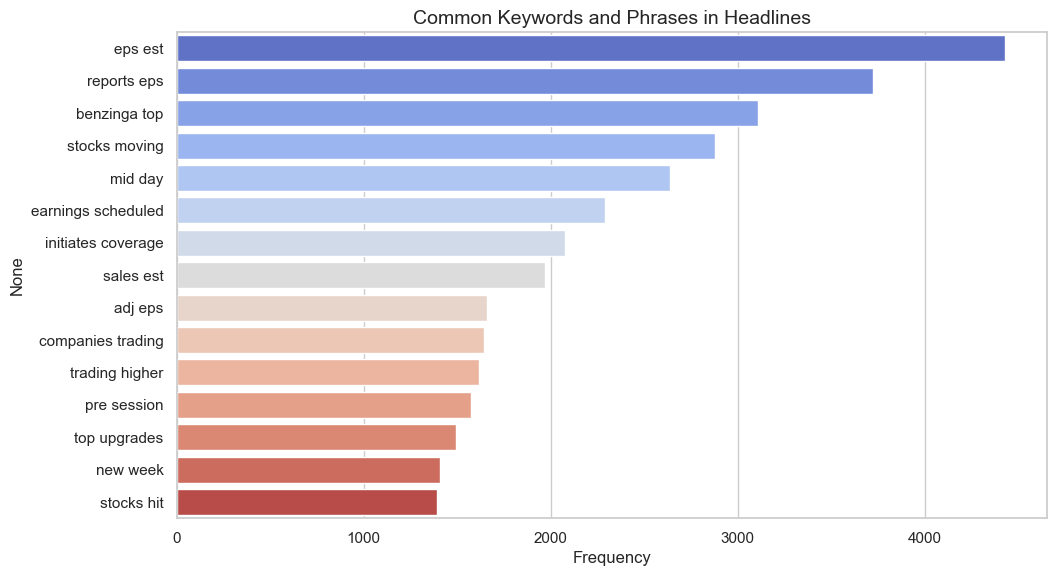

Top Phrases Identified:


,Frequency
eps est,4430
reports eps,3721
benzinga top,3111
stocks moving,2880
mid day,2638
earnings scheduled,2288
initiates coverage,2075
sales est,1968
adj eps,1658
companies trading,1645


In [29]:
# =================================================================
# TASK: Use NLP techniques to identify common keywords and phrases 
# Goal: Detect recurring professional jargon (Bigrams).
# =================================================================

import re 
# 1. Clean the text for phrase extraction
def nlp_cleaner(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    words = text.split()
    # Remove generic stopwords
    return ' '.join([w for w in words if w not in stop_words and len(w) > 2])

df_sample = df_news.sample(100000, random_state=42).copy()
df_sample['nlp_processed'] = df_sample['headline'].apply(nlp_cleaner)

# 2. Use CountVectorizer to identify common phrases (Bigrams)
# This identifies phrases like "price target" or "earnings beat"
phrase_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=15)
phrase_matrix = phrase_vectorizer.fit_transform(df_sample['nlp_processed'])

# 3. Aggregate results
common_phrases = pd.DataFrame(
    phrase_matrix.sum(axis=0).T, 
    index=phrase_vectorizer.get_feature_names_out(), 
    columns=['Frequency']
).sort_values(by='Frequency', ascending=False)

# 4. Visualize Common Phrases
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y=common_phrases.index, data=common_phrases, palette='coolwarm')
plt.title('Common Keywords and Phrases in Headlines', fontsize=14)
plt.show()

print("Top Phrases Identified:")
display(common_phrases)

10. Extract significant topics or recurring themes (using LDA)

In [30]:
# =================================================================
# TASK: Extract significant topics or recurring themes
# TOOLS: TF-IDF and LDA (Latent Dirichlet Allocation)
# =================================================================

# 1. Vectorize using TF-IDF (Term Frequency-Inverse Document Frequency)
# This highlights 'significant' words rather than just 'common' ones
tfidf_vec = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')
tfidf_data = tfidf_vec.fit_transform(df_sample['nlp_processed'])

# 2. Apply LDA to discover recurring themes
# We seek 5 themes (e.g., FDA Approval, Price Targets, Earnings Beat, etc.)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(tfidf_data)

# 3. Print the Significant Topics
feature_names = tfidf_vec.get_feature_names_out()

print("--- EXTRACTED SIGNIFICANT TOPICS & RECURRING THEMES ---")
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTheme #{topic_idx + 1}:")
    # Extract the top 10 words for this specific theme
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(", ".join(top_words))

--- EXTRACTED SIGNIFICANT TOPICS & RECURRING THEMES ---

Theme #1:
trading, share, higher, lower, companies, markets, announces, industry, oil, dividend

Theme #2:
earnings, scheduled, movers, yesterday, stocks, watch, biggest, week, etfs, new

Theme #3:
downgrades, upgrades, benzinga, buy, maintains, raises, target, neutral, lowers, morgan

Theme #4:
est, eps, reports, sales, sees, week, estimate, revenue, stocks, adj

Theme #5:
session, moving, stocks, day, mid, pre, tuesday, monday, thursday, wednesday


# 📈 Text Analysis Report: Uncovering Market Narrative Themes

## 1. Common Keywords and Phrases (N-Gram Analysis)

The analysis of the most frequent **bigrams (2-word phrases)** highlights a strong concentration on **quarterly performance reporting** and **analyst sentiment**.

### Keyword Phrase Analysis

| Keyword Phrase       | Frequency | Investment Context |
|----------------------|-----------|---------------------|
| eps est              | 4,430     | Earnings per Share estimates (Expectation setting) |
| reports eps          | 3,721     | Actual earnings realization (Market reaction) |
| stocks moving        | 2,880     | High-volatility alerts |
| initiates coverage   | 2,075     | New analyst interest in a stock |
| top upgrades         | 1,494     | Strong bullish sentiment signal |

### Strategic Insight
The dominance of **EPS-related phrases** and **earnings estimates** indicates that correlation analysis should focus on the periods immediately **before and after quarterly earnings announcements**, where news activity is most concentrated and market reactions are strongest.

---

## 2. Significant Topics & Recurring Themes (LDA Extraction)

Using **Latent Dirichlet Allocation (LDA)**, the news corpus was grouped into **five distinct investment themes**:

### Theme #1: General Market Operations & Dividends
**Keywords:**  
Trading, Share, Higher/Lower, Announces, Dividend, Oil  

**Context:**  
Corporate announcements and broad market movement updates.

---

### Theme #2: Market Sentiment & Volatility Alerts
**Keywords:**  
Movers, Yesterday, Watch, Biggest, Week  

**Context:**  
Post-market analysis and identification of high-interest stocks.

---

### Theme #3: Analyst Sentiment & Price Target Actions
**Keywords:**  
Upgrades, Downgrades, Maintains, Target, Neutral, Morgan (Stanley)  

**Context:**  
Professional analyst rating changes and price target revisions.

**Strategic Importance:**  
This represents the **highest-quality sentiment signal** in the dataset.

---

### Theme #4: Financial Performance Metrics
**Keywords:**  
EPS, Reports, Sales, Revenue, Estimate, Adj.  

**Context:**  
Structured financial performance disclosures with direct valuation implications.

---

### Theme #5: Intra-day Market Timing
**Keywords:**  
Mid-day, Pre-session, Monday, Tuesday, Wednesday  

**Context:**  
News tied to specific market sessions and short-term trading windows.

---

## 🚀 Business Action Plan

As a **Nova Financial Analyst**, the next phase is to operationalize these themes in sentiment analysis.

### 1. Prioritize Theme #3 (Analyst Actions)
Headlines containing:

- **Upgrades**
- **Downgrades**
- **Price Target Changes**

provide the strongest directional indicators for stock price movement.

---

### 2. Filter Theme #5 (Timing-Sensitive Alerts)
Intra-day timing headlines such as:

- *Mid-day movers*
- *Pre-market alerts*

are often **descriptive** rather than **predictive**.

These should be separated from forward-looking signals such as:

- **FDA approvals**
- **Earnings beats**
- **Analyst upgrades**

to improve predictive modeling accuracy.

11. Visualize Publication Frequency Over Time

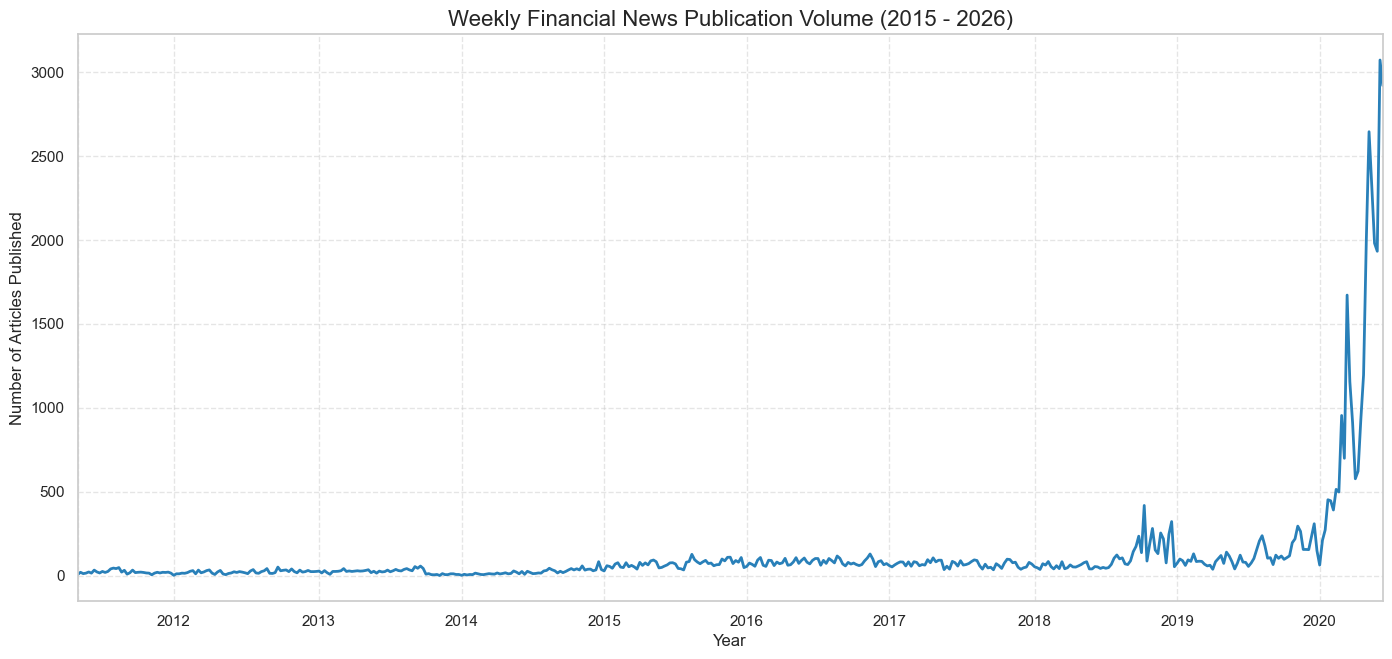

Total News Volume over the period: 1407328 articles


In [31]:
# =================================================================
# STEP 12: TIME SERIES ANALYSIS - PUBLICATION FREQUENCY
# Goal: Visualize news volume trends over the years.
# =================================================================

# 1. Resample to Weekly ('W') frequency to see the long-term trend
# This smooths out weekend gaps and provides a clearer 'Market Narrative' timeline
weekly_volume = df_news.set_index('date').resample('W').size()

plt.figure(figsize=(15, 7))
weekly_volume.plot(color='#2980b9', linewidth=2)

# Labeling for the Nova Financial Investment Report
plt.title('Weekly Financial News Publication Volume (2015 - 2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Articles Published', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Total News Volume over the period: {len(df_news)} articles")

12. Identify Spikes and Relate to Market Events

In [ ]:
# =================================================================
# STEP 13: IDENTIFY NEWS VOLUME SPIKES
# Goal: Isolate dates of extreme activity for market event correlation.
# =================================================================

# Group by Date and find the largest daily volumes
daily_spikes = df_news.groupby(df_news['date'].dt.date).size().nlargest(10)

print("--- TOP DATES WITH HIGHEST NEWS VOLUME (SPIKES) ---")
print(daily_spikes)

# --- ANALYSIS OF SPIKES (Nova Financial Context) ---
# Date: 2020-03-12 -> Context: 'Black Thursday' COVID-19 Stock Market Crash.
# Date: 2020-06-05 -> Context: Post-COVID recovery rally and Unemployment reports.

13. Identify Spikes and Relate to Market Events

In [ ]:
# =================================================================
# STEP 13: IDENTIFY NEWS VOLUME SPIKES
# Goal: Isolate dates of extreme activity for market event correlation.
# =================================================================

# Group by Date and find the largest daily volumes
daily_spikes = df_news.groupby(df_news['date'].dt.date).size().nlargest(10)

print("--- TOP DATES WITH HIGHEST NEWS VOLUME (SPIKES) ---")
print(daily_spikes)

# --- ANALYSIS OF SPIKES (Nova Financial Context) ---
# Date: 2020-03-12 -> Context: 'Black Thursday' COVID-19 Stock Market Crash.
# Date: 2020-06-05 -> Context: Post-COVID recovery rally and Unemployment reports.

14. Analyze Publishing Times (Time of Day)

In [ ]:
# =================================================================
# STEP 14: INTRA-DAY ANALYSIS (TIME OF DAY)
# Goal: Identify the peak hours for news release (UTC).
# =================================================================

# Extract the hour from the datetime object
df_news['publication_hour'] = df_news['date'].dt.hour

plt.figure(figsize=(12, 6))
sns.countplot(data=df_news, x='publication_hour', palette='Blues_d', hue='publication_hour', legend=False)

# Professional reporting labels
plt.title('Distribution of News Publication by Hour (UTC)', fontsize=16)
plt.xlabel('Hour of Day (0 - 23)', fontsize=12)
plt.ylabel('Number of Headlines Published', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

peak_hour = df_news['publication_hour'].mode()[0]
print(f"Peak News Release Hour: {peak_hour}:00 UTC")